<a href="https://colab.research.google.com/github/hemang1694/house-price-prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction

This project aims to predict whether a customer will churn (leave the service) or not using machine learning techniques.

Churn prediction is important for businesses because it helps in retaining customers and improving services.

We use classification models like Logistic Regression and Random Forest to solve this problem.

STEP 1: Import Libraries

In [ ]:
import pandas as pd          # for handling data (tables like Excel)
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt  # for graphs
import seaborn as sns        # for better visualizations

STEP 2: Load Dataset


In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')  # load CSV file into dataframe
df.head()  # show first 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


STEP 3: Understand Data

In [ ]:
df.info()  # shows data types + missing values
df.isnull().sum()  # count missing values in each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


We check the dataset for missing values and data types.
Some columns like TotalCharges are stored as object and need conversion.

STEP 4: Data Cleaning

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)


TotalCharges is converted to numeric format.
Missing values are removed and customerID is dropped as it is not useful for prediction.

STEP 5: Convert Categorical → Numeric (ENCODING)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

Machine learning models require numeric input, so categorical values are converted using Label Encoding.

step 6. EDA

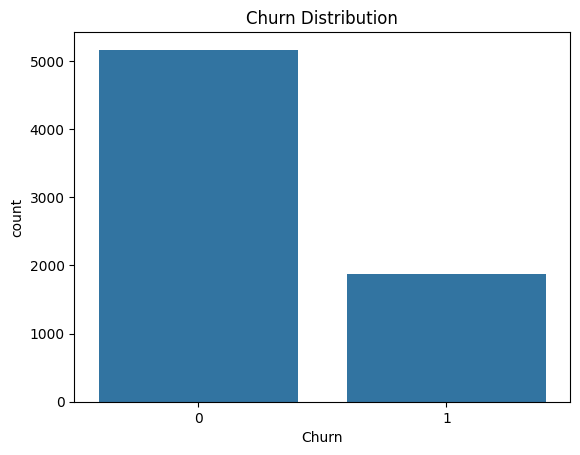

In [ ]:
#Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

This graph shows how many customers have churned vs stayed.

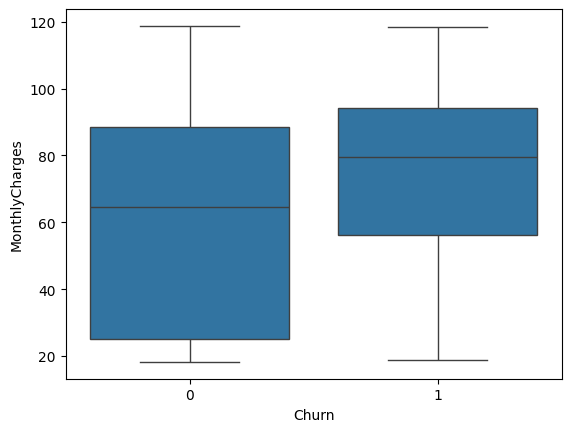

In [ ]:
# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

Customers with higher monthly charges are more likely to churn.

STEP 7: Split Data

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)  # features (inputs)
y = df['Churn']               # target (output)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Data is split into training (80%) and testing (20%) sets.

STEP 8: Train Model

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)  # create model
lr.fit(X_train, y_train)  # train model

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Logistic Regression is used for binary classification problems.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

Random Forest is used because it handles complex relationships and improves accuracy.

STEP 9: Prediction & Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7896233120113717


In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_pred))

ROC AUC: 0.6912709464671198


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



STEP 9: Confusion Matrix


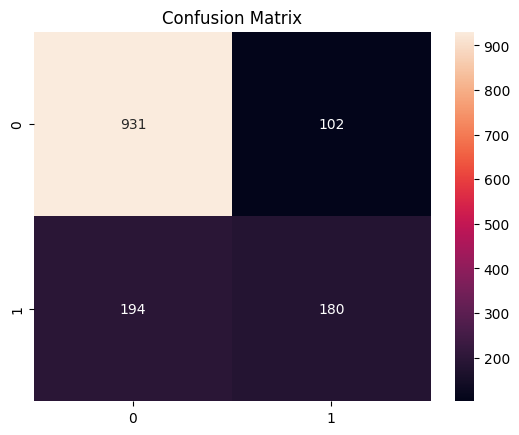

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Confusion matrix helps to understand correct and incorrect predictions.


STEP 10: SHAP (Explain Model)

In [ ]:
!pip install shap
import shap


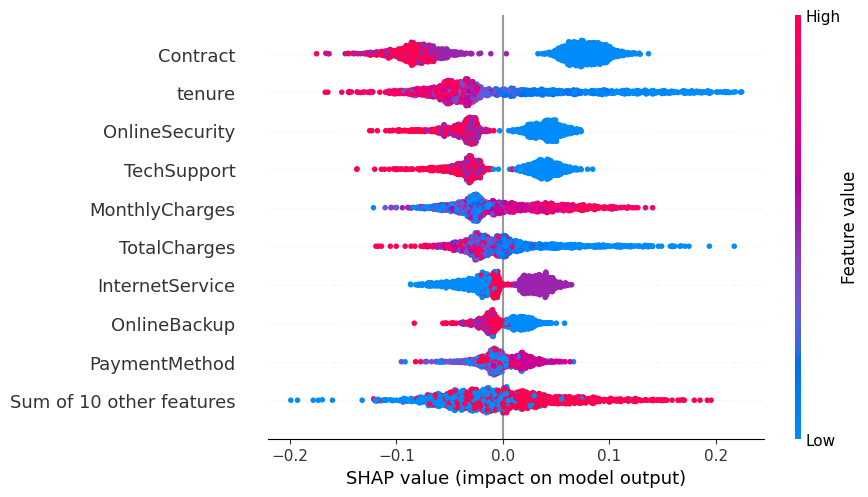

In [ ]:
import shap

explainer = shap.Explainer(rf)
shap_values = explainer(X_test)

# Select only churn class (class 1)
shap.plots.beeswarm(shap_values[:, :, 1])

SHAP is used to explain machine learning model predictions by showing the impact of each feature on the output. It helps convert complex models into interpretable results.


# Business Insights

- Customers with low tenure are more likely to churn
- High monthly charges increase churn
- Customers with short-term contracts churn more

# Recommendations

- Offer discounts to new customers
- Promote long-term plans
- Improve service for high-paying users


This project successfully predicts customer churn using machine learning models.
Random Forest performed better than Logistic Regression.

Understanding customer behavior can help companies reduce churn and increase profit.